In [1]:
# Libraies 
import pandas as pd 
import numpy as np
# For visualization
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display
from tabulate import tabulate

In [2]:
# Load Dataset
df1=pd.read_csv('retail_sales_dataset.csv')
df=df1.copy()
print(df.shape)
df.head()


(1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print('Dataset Overview -')
df.info()
# Cheacking for Missing\NUll
missing_df=df.isnull().sum()
print(missing_df)
# Cheacking for Duplicates
duplicate=df.duplicated().sum()
print(duplicate)


Dataset Overview -
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
0


In [4]:
# Data cleaning
df['Date']=pd.to_datetime(df['Date'])
print(df['Date'].head())


0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]


In [5]:
# Unique Values
uni_val=df.nunique()
print('Unique Value Counts:','\n', uni_val)

Unique Value Counts: 
 Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64


Dataset-Level KPIs
Total Revenue: $456,000.00
Total Transactions: 1000
Average Transaction Value: $456.00
Age Range: 18 - 64
Price per Unit Range: $25.00 - $500.00
Transaction Amount Range: $25.00 - $2000.00


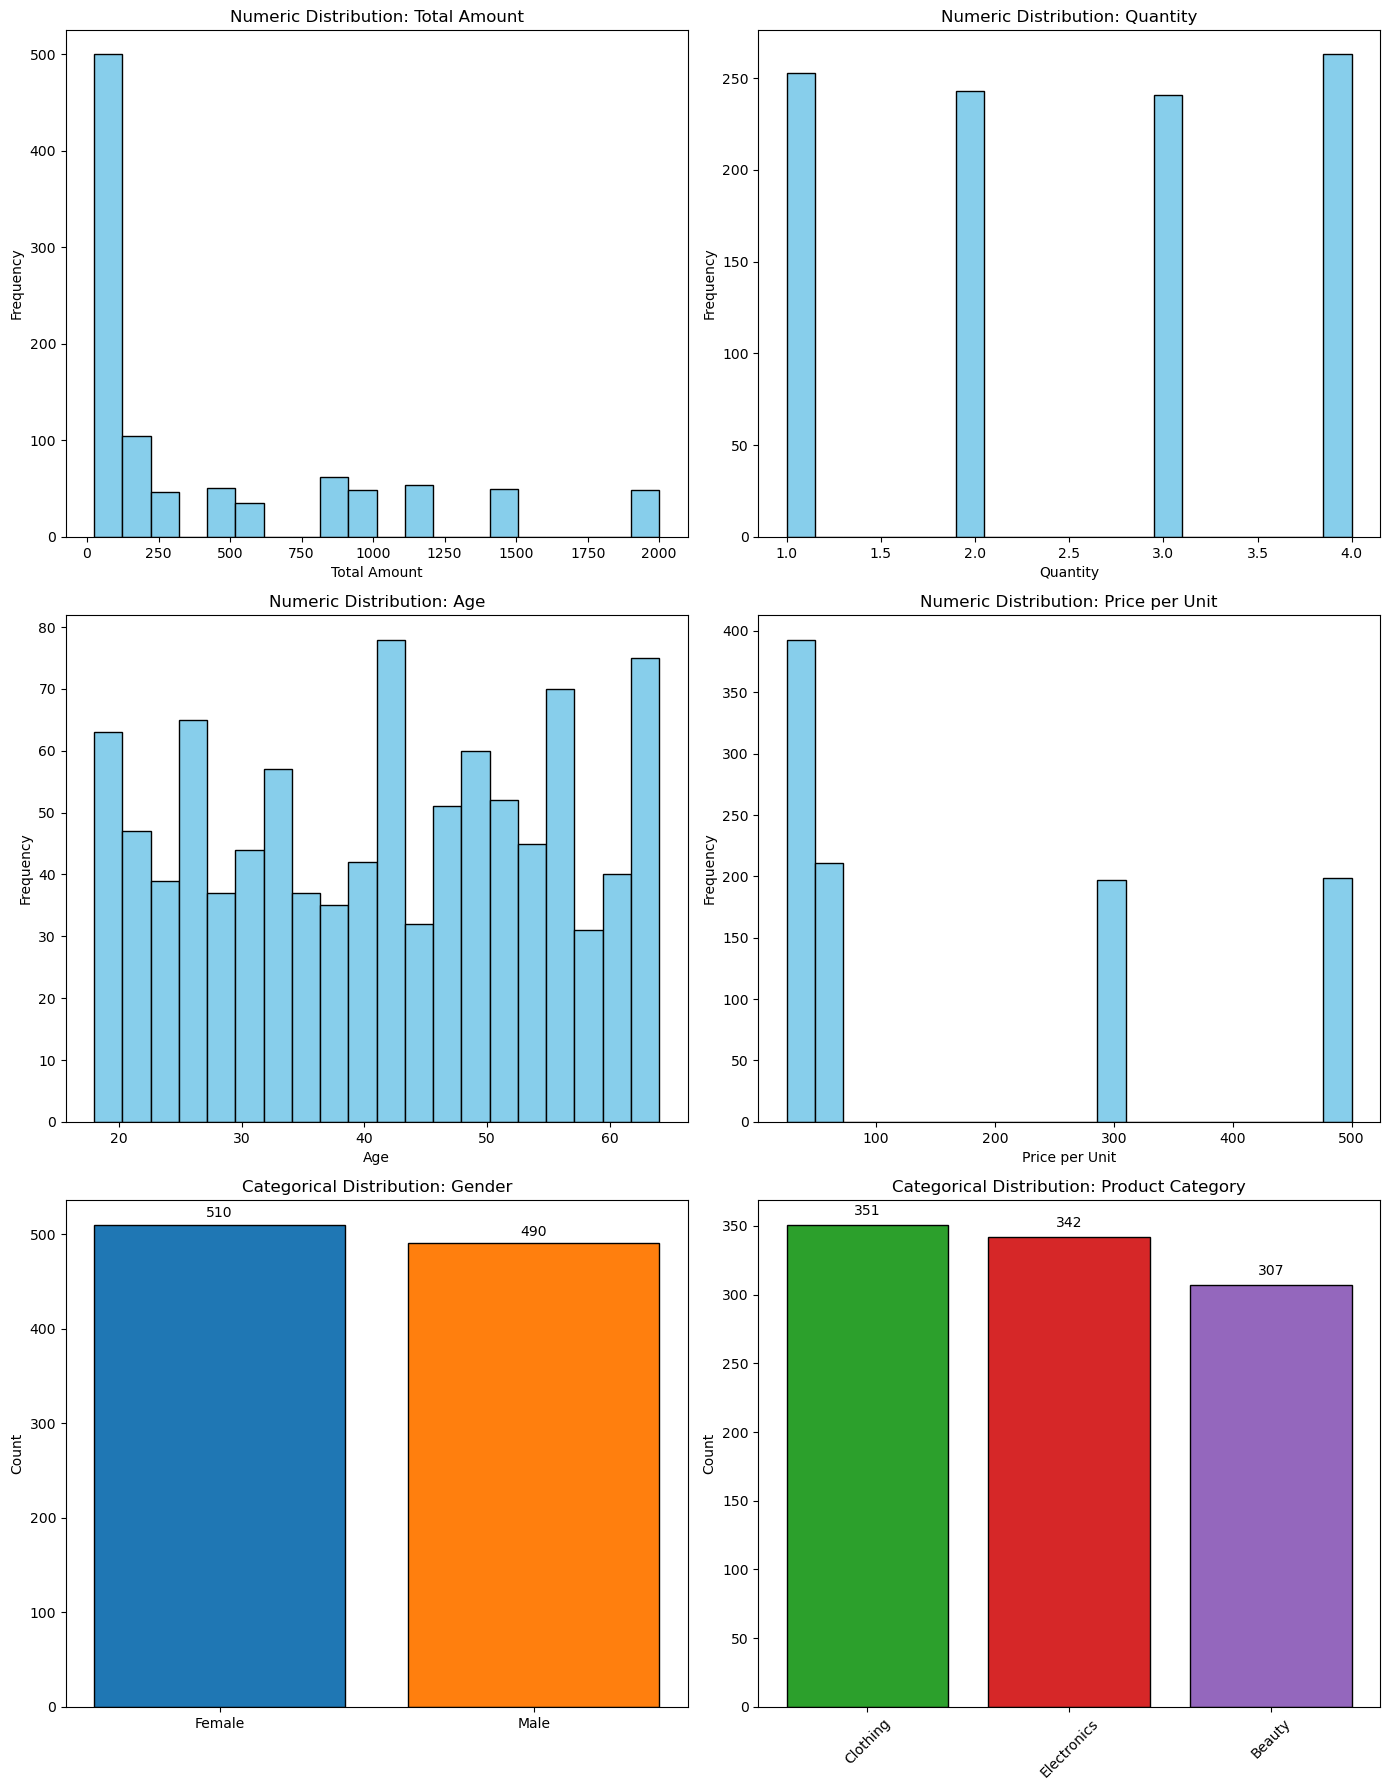

In [6]:
# Understanding the data (KPIs)
tot_revenue = df['Total Amount'].sum()
tot_transactions = df['Transaction ID'].nunique()
avg_transaction_value = df['Total Amount'].mean()

# Ranges for customer demographics & spending
min_age=df['Age'].min()
max_age=df['Age'].max()
min_price_per_unit = df['Price per Unit'].min()
max_price_per_unit = df['Price per Unit'].max()
min_transaction_amount = df.groupby('Transaction ID')['Total Amount'].sum().min()
max_transaction_amount = df.groupby('Transaction ID')['Total Amount'].sum().max()

# KPIs
print("Dataset-Level KPIs")
print(f"Total Revenue: ${tot_revenue:,.2f}")
print(f"Total Transactions: {tot_transactions}")
print(f"Average Transaction Value: ${avg_transaction_value:,.2f}")
print(f"Age Range: {min_age} - {max_age}")
print(f"Price per Unit Range: ${min_price_per_unit:.2f} - ${max_price_per_unit:.2f}")
print(f"Transaction Amount Range: ${min_transaction_amount:.2f} - ${max_transaction_amount:.2f}")

# --- COLUMN GROUPING ---
numeric_cols = ['Total Amount', 'Quantity', 'Age', 'Price per Unit']
categorical_cols = ['Gender', 'Product Category']

# --- PLOTTING DISTRIBUTIONS ---
tot_plots = len(numeric_cols) + len(categorical_cols)
cols = 2
rows = (tot_plots + 1) // cols

plt.figure(figsize=(14, 6*rows))

# Numeric distributions (histograms)
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Numeric Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
# Categorical: Gender
# Gender with different colors
plt.subplot(rows, cols, len(numeric_cols)+1)
gender_counts = df['Gender'].value_counts()
colors = ['#1f77b4', '#ff7f0e']  # Blue for Male, Orange for Female (adjust as needed)
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black')
plt.title('Categorical Distribution: Gender')
plt.ylabel('Count')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)), ha='center', va='bottom')

# Categorical: Product Category
plt.subplot(rows, cols, len(numeric_cols)+2)
product_counts = df['Product Category'].value_counts()
colors = ['#2ca02c', '#d62728', '#9467bd']  # Different colors per category
bars = plt.bar(product_counts.index, product_counts.values, color=colors, edgecolor='black')
plt.title('Categorical Distribution: Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Table 1: Top 10 Customers by Revenue


,Customer ID,Gender,Age,Top_Product_Category,Total_Transactions,Total_Quantity,Total_Revenue,Avg_Transaction_Value
14,CUST015,Female,42,Electronics,1,4,2000,2000.0
412,CUST412,Female,19,Electronics,1,4,2000,2000.0
970,CUST970,Male,59,Electronics,1,4,2000,2000.0
547,CUST547,Male,63,Clothing,1,4,2000,2000.0
281,CUST281,Female,29,Beauty,1,4,2000,2000.0
416,CUST416,Male,53,Electronics,1,4,2000,2000.0
420,CUST420,Female,22,Clothing,1,4,2000,2000.0
927,CUST927,Male,43,Electronics,1,4,2000,2000.0
447,CUST447,Male,22,Beauty,1,4,2000,2000.0
342,CUST342,Female,43,Clothing,1,4,2000,2000.0


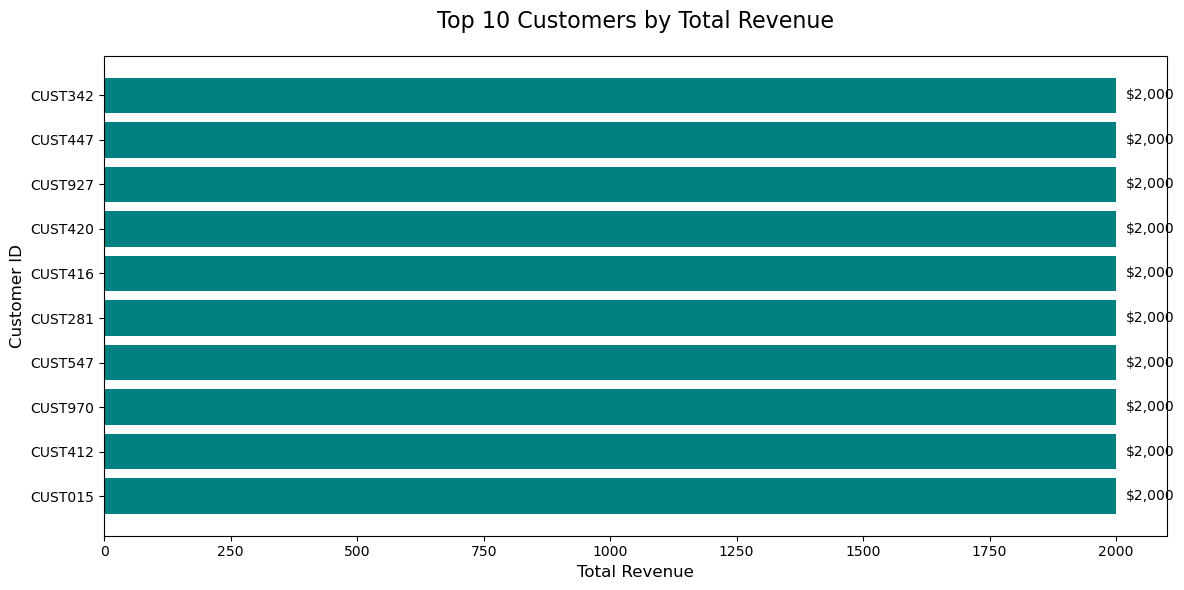

In [7]:
### Q1 Who are our most valuable customers?
##  Valued Customers(High spending)
#   Summarize revenue & transcantion
customer_summary = df.groupby('Customer ID').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Transaction_Value=('Total Amount', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Age=('Age', 'first'),  # Assuming age is same per customer
    Gender=('Gender', 'first'),  # Assuming gender is same per customer
    Top_Product_Category=('Product Category', lambda x: x.mode()[0])  # Most frequent product category
).reset_index()

# Extract top 10 customers by revenue
top_customers = customer_summary.sort_values(by='Total_Revenue', ascending=False).head(10)

# Display top customers in a table
print("Table 1: Top 10 Customers by Revenue")
display(top_customers[['Customer ID', 'Gender', 'Age', 'Top_Product_Category', 
                       'Total_Transactions', 'Total_Quantity', 'Total_Revenue', 'Avg_Transaction_Value']])

# Visualize with a horizontal bar chart
top_customers_sorted = top_customers.sort_values(by='Total_Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.barh(
    top_customers_sorted['Customer ID'],
    top_customers_sorted['Total_Revenue'],
    color='teal'
)

# Add labels showing revenue value at bar ends
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (top_customers_sorted['Total_Revenue'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        ha='left',
        va='center',
        fontsize=10
    )

ax.set_title('Top 10 Customers by Total Revenue', fontsize=16, pad=20)
ax.set_xlabel('Total Revenue', fontsize=12)
ax.set_ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.show()

Table 2A: Top 10 Ages by Total Revenue


,Age,Total_Revenue,Total_Transactions,Avg_Transaction_Value,Num_Customers
25,43,17970,31,579.677419,31
16,34,16785,28,599.464286,28
33,51,16065,30,535.500000,30
1,19,14870,21,708.095238,21
8,26,13980,22,635.454545,22
4,22,13700,27,507.407407,27
28,46,13090,25,523.600000,25
3,21,12585,20,629.250000,20
29,47,12505,26,480.961538,26
19,37,11650,16,728.125000,16


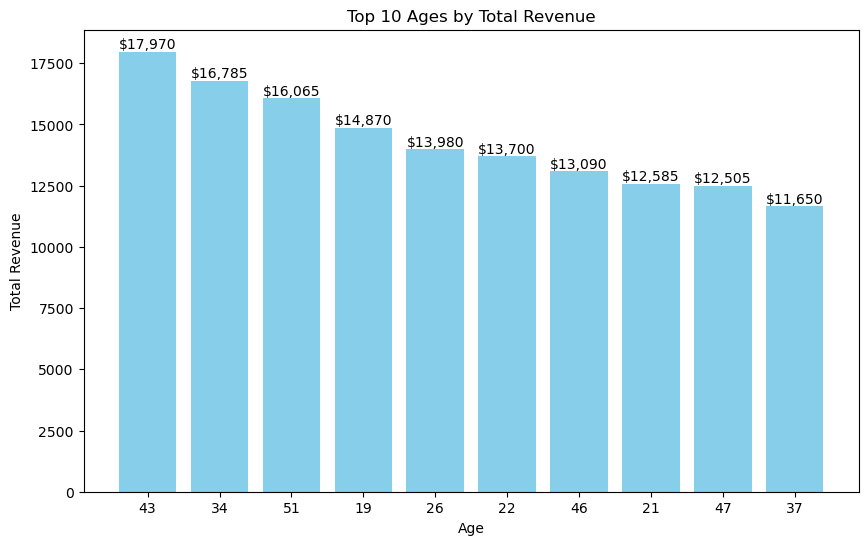


Table 2B: Spending Summary by Gender


,Gender,Total_Revenue,Total_Transactions,Avg_Transaction_Value,Num_Customers
0,Female,232840,510,456.549020,510
1,Male,223160,490,455.428571,490


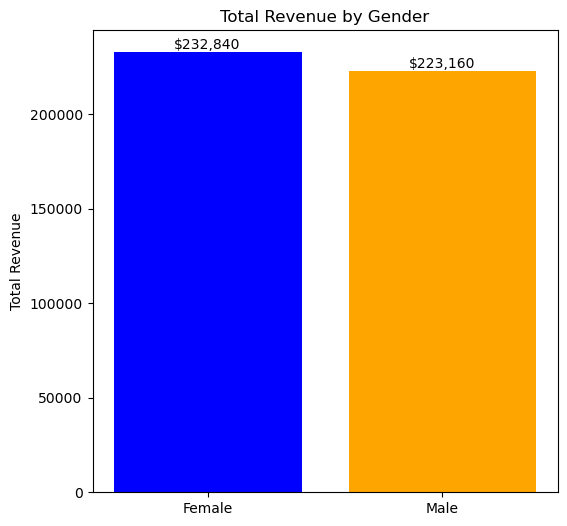


Table 2C: Top Age & Gender Combinations by Total Revenue


,Age,Gender,Total_Revenue,Total_Transactions,Avg_Transaction_Value,Num_Customers
32,34,Female,12050,14,860.714286,14
16,26,Female,10375,15,691.666667,15
50,43,Female,10260,19,540.000000,19
67,51,Male,8795,13,676.538462,13
9,22,Male,8275,13,636.538462,13
27,31,Male,8200,16,512.500000,16
91,63,Male,8045,11,731.363636,11
0,18,Female,7940,13,610.769231,13
57,46,Male,7710,9,856.666667,9
51,43,Male,7710,12,642.500000,12


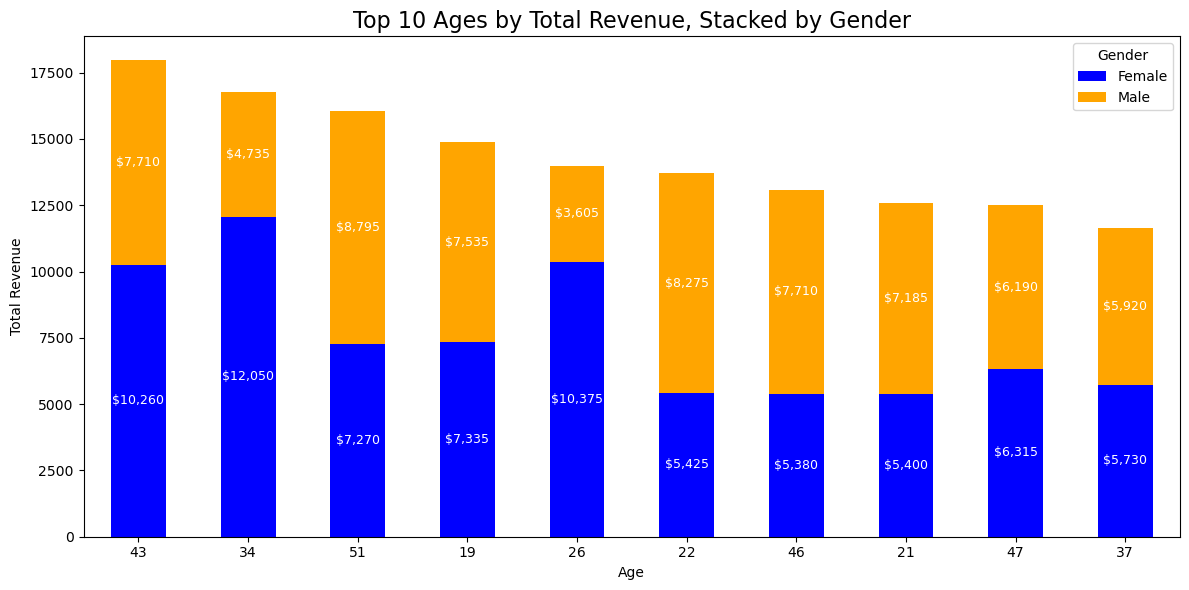

In [8]:
### Q2 How does customer age and gender influence purchasing behavior?
##  Spending patterns by age, gender, and their combination
#   Agg revenue and transcation by age
age_summary = df.groupby('Age').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Transaction_Value=('Total Amount', 'mean'),
    Num_Customers=('Customer ID', 'nunique')
).reset_index()

# Extract top 10 ages by revenue
top_age_summary = age_summary.sort_values(by='Total_Revenue', ascending=False).head(10)

# Display table
print("Table 2A: Top 10 Ages by Total Revenue")
display(top_age_summary)

# Visualize with bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(top_age_summary['Age'].astype(str), top_age_summary['Total_Revenue'], color='skyblue')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=10)
plt.title('Top 10 Ages by Total Revenue')
plt.xlabel('Age')
plt.ylabel('Total Revenue')
plt.show()


## Total Spending by Gender

# Aggregate revenue and transactions by gender
gender_summary = df.groupby('Gender').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Transaction_Value=('Total Amount', 'mean'),
    Num_Customers=('Customer ID', 'nunique')
).reset_index()

# Display table
print("\nTable 2B: Spending Summary by Gender")
display(gender_summary)

# Step 3: Visualize with bar chart
plt.figure(figsize=(6,6))
colors = ['blue' if g=='Female' else 'orange' for g in gender_summary['Gender']]
bars = plt.bar(gender_summary['Gender'], gender_summary['Total_Revenue'], color=colors)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=10)
plt.title('Total Revenue by Gender')
plt.ylabel('Total Revenue')
plt.show()


## Spending by Age & Gender (Stacked Bar)
# Step 1: Aggregate by age + gender
age_gender_summary = df.groupby(['Age','Gender']).agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Transaction_Value=('Total Amount', 'mean'),
    Num_Customers=('Customer ID', 'nunique')
).reset_index()

# Show top 10 age-gender combos by revenue
print("\nTable 2C: Top Age & Gender Combinations by Total Revenue")
top_age_gender_table = age_gender_summary.sort_values(by='Total_Revenue', ascending=False).head(10)
display(top_age_gender_table)

# Prepare data for stacked bar chart
stacked_data = age_gender_summary.pivot(index='Age', columns='Gender', values='Total_Revenue')
top_ages = stacked_data.sum(axis=1).sort_values(ascending=False).head(10).index
stacked_data_top = stacked_data.loc[top_ages]

# Visualize stacked bar chart
fig, ax = plt.subplots(figsize=(12,6))
stacked_data_top.plot(kind='bar', stacked=True, ax=ax, color=['blue', 'orange'])

# Add labels inside the bars
for i, age in enumerate(stacked_data_top.index):
    bottom = 0
    for gender in stacked_data_top.columns:
        val = stacked_data_top.loc[age, gender]
        ax.text(i, bottom + val/2, f"${val:,.0f}", ha='center', va='center', fontsize=9, color='white')
        bottom += val

ax.set_title('Top 10 Ages by Total Revenue, Stacked by Gender', fontsize=16)
ax.set_xlabel('Age')
ax.set_ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Table 3A: Revenue, Number of Customers, and Average Transaction Value per Product Category


,Product Category,Total_Revenue,Number_of_Customers,Avg_Transaction_Value
2,Electronics,156905,342,458.786550
1,Clothing,155580,351,443.247863
0,Beauty,143515,307,467.475570


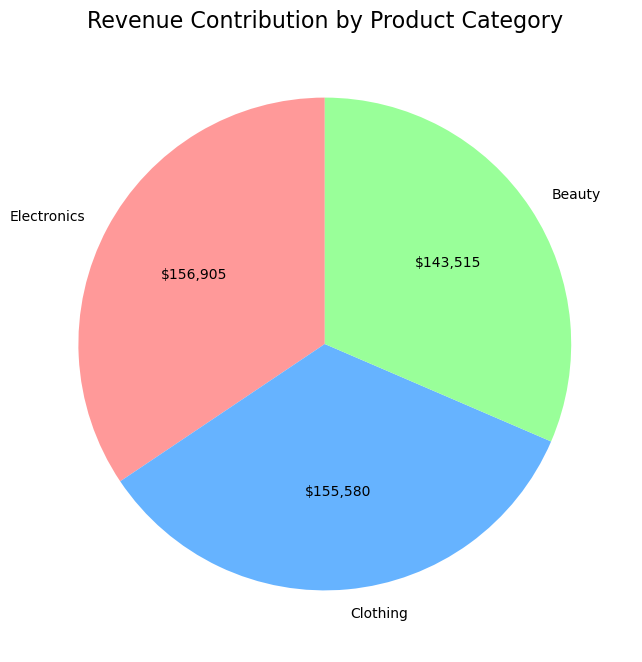

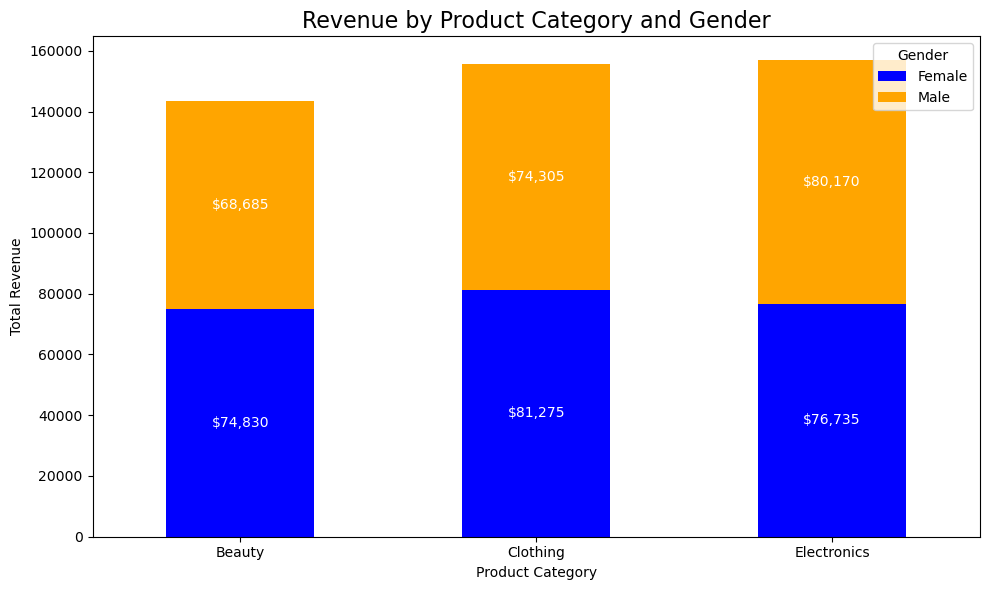


Table 3B: Revenue, Number of Customers, and Average Transaction Value by Product Category & Gender


,Product Category,Gender,Total_Revenue,Number_of_Customers,Avg_Transaction_Value
2,Clothing,Female,81275,174,467.097701
5,Electronics,Male,80170,172,466.104651
4,Electronics,Female,76735,170,451.382353
0,Beauty,Female,74830,166,450.783133
3,Clothing,Male,74305,177,419.802260
1,Beauty,Male,68685,141,487.127660



Table 3C: Top 3 Age & Gender Combinations by Revenue per Product


,Product Category,Age,Gender,Total_Revenue,Number_of_Customers
0,Beauty,46,Male,6160,6
1,Beauty,34,Female,5350,7
2,Beauty,21,Male,4700,4
3,Clothing,26,Female,6960,7
4,Clothing,64,Female,4735,10
5,Clothing,43,Female,4175,7
6,Electronics,63,Male,5675,7
7,Electronics,34,Female,5400,5
8,Electronics,43,Male,5350,5


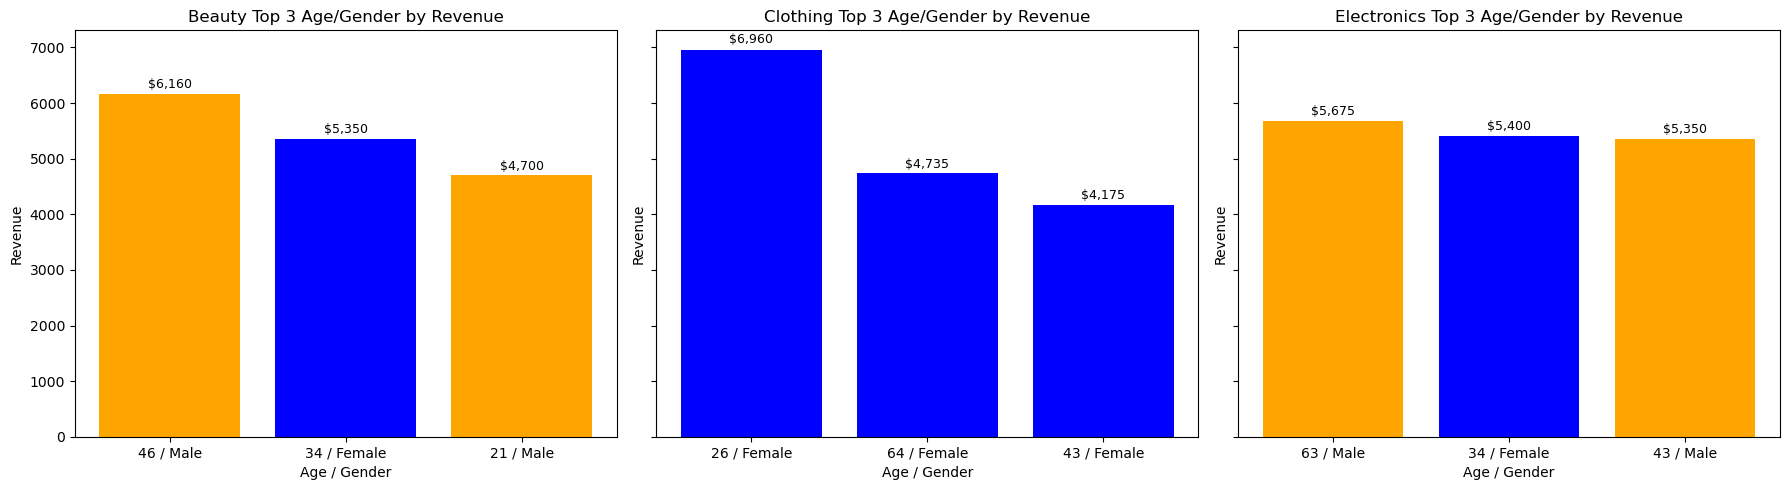

In [9]:
### Q3 Which product categories drive the most revenue?
##  Top revenue-generating products and analyze by gender/age
#   Revenue & Number of Customers per Product Category
product_summary = df.groupby('Product Category').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Number_of_Customers=('Customer ID', 'nunique'),
    Avg_Transaction_Value=('Total Amount','mean')
).reset_index()

# Sort categories by revenue
product_summary = product_summary.sort_values(by='Total_Revenue', ascending=False)

# Display summary table
print("Table 3A: Revenue, Number of Customers, and Average Transaction Value per Product Category")
display(product_summary)

# Visualize revenue distribution as a pie chart
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(
    product_summary['Total_Revenue'],
    labels=product_summary['Product Category'],
    autopct=lambda p: f"${p*product_summary['Total_Revenue'].sum()/100:,.0f}",
    colors=['#ff9999','#66b3ff','#99ff99'],
    startangle=90
)
ax.set_title('Revenue Contribution by Product Category', fontsize=16)
plt.show()

## Revenue by Product Category & Gender
# Aggregate revenue and customer count per product & gender
product_gender_summary = df.groupby(['Product Category','Gender']).agg(
    Total_Revenue=('Total Amount','sum'),
    Number_of_Customers=('Customer ID','nunique'),
    Avg_Transaction_Value=('Total Amount','mean')
).reset_index()

# Pivot for stacked bar chart
stacked_product_gender = product_gender_summary.pivot(index='Product Category', columns='Gender', values='Total_Revenue')

# Visualize revenue split by gender for each product
fig, ax = plt.subplots(figsize=(10,6))
stacked_product_gender.plot(kind='bar', stacked=True, ax=ax, color=['blue','orange'])

# Add labels inside bars
for i, product in enumerate(stacked_product_gender.index):
    bottom = 0
    for gender in stacked_product_gender.columns:
        val = stacked_product_gender.loc[product, gender]
        ax.text(i, bottom + val/2, f"${val:,.0f}", ha='center', va='center', fontsize=10, color='white')
        bottom += val

ax.set_title('Revenue by Product Category and Gender', fontsize=16)
ax.set_ylabel('Total Revenue')
ax.set_xlabel('Product Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display table
print("\nTable 3B: Revenue, Number of Customers, and Average Transaction Value by Product Category & Gender")
display(product_gender_summary.sort_values(by='Total_Revenue', ascending=False))

## Top 3 Age & Gender Combinations per Product
# Aggregate revenue per product, age, and gender
age_gender_product_summary = df.groupby(['Product Category','Age','Gender']).agg(
    Total_Revenue=('Total Amount','sum'),
    Number_of_Customers=('Customer ID','nunique')
).reset_index()

top3_age_gender_per_product = (
    age_gender_product_summary
    .sort_values(['Product Category', 'Total_Revenue'], ascending=[True, False])
    .groupby('Product Category')
    .head(3)
    .reset_index(drop=True)
)

# Display table
print("\nTable 3C: Top 3 Age & Gender Combinations by Revenue per Product")
display(top3_age_gender_per_product.sort_values(by=['Product Category','Total_Revenue'], ascending=[True, False]))

# Grouped bar chart per product
fig, axs = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for i, product in enumerate(top3_age_gender_per_product['Product Category'].unique()):
    data = top3_age_gender_per_product[top3_age_gender_per_product['Product Category']==product]
    labels = data['Age'].astype(str) + ' / ' + data['Gender']
    axs[i].bar(labels, data['Total_Revenue'], color=['blue' if g=='Female' else 'orange' for g in data['Gender']])
    axs[i].set_title(f"{product} Top 3 Age/Gender by Revenue")
    axs[i].set_xlabel('Age / Gender')
    axs[i].set_ylabel('Revenue')
    for idx, val in enumerate(data['Total_Revenue']):
        axs[i].text(idx, val + val*0.01, f"${val:,.0f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Table 4: Monthly Sales Table


,Month,Total_Revenue,Total_Transactions,Avg_Transaction_Value
0,1,36980,78,474.102564
1,2,44060,85,518.352941
2,3,28990,73,397.123288
3,4,33870,86,393.837209
4,5,53150,105,506.190476
5,6,36715,77,476.818182
6,7,35465,72,492.569444
7,8,36960,94,393.191489
8,9,23620,65,363.384615
9,10,46580,96,485.208333


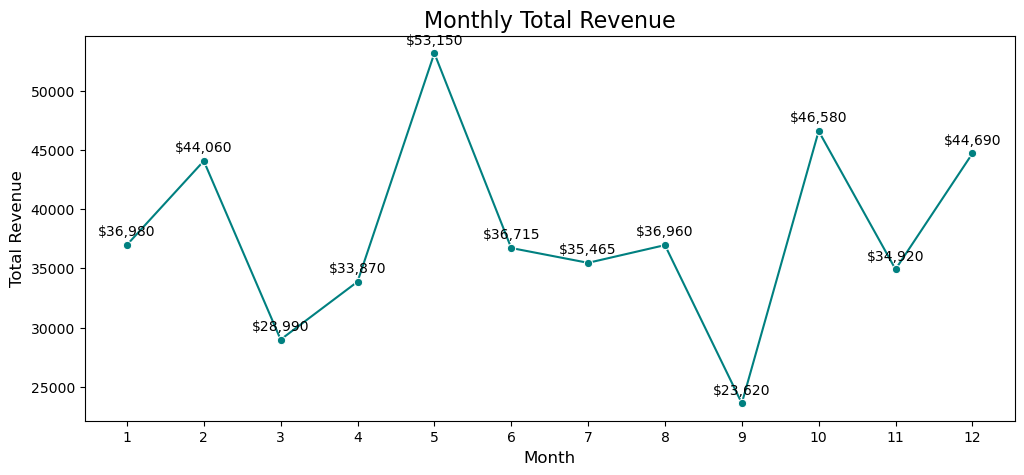

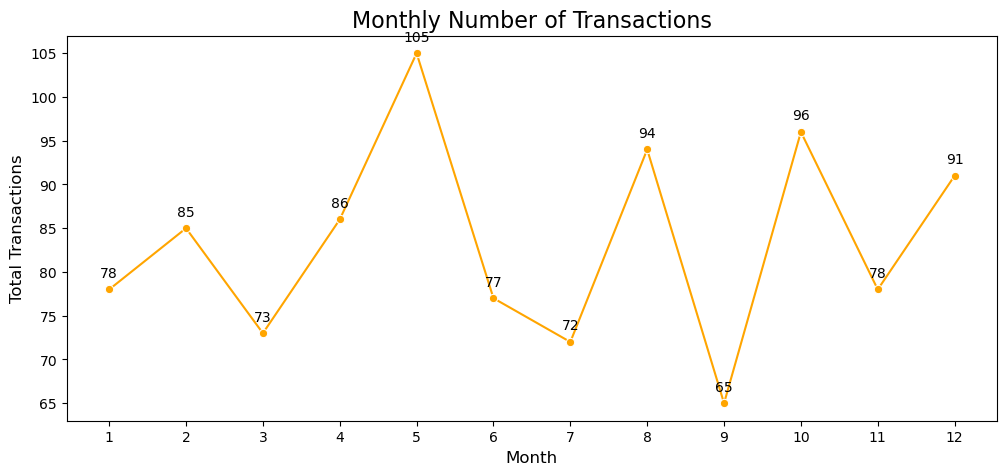

In [10]:
### Q4 Monthly trends in sales and transactions
##  Identify seasonality patterns in revenue and transactions
#   Aggregate Monthly Sales Metrics
df['Month'] = df['Date'].dt.month

# Aggregate revenue & transactions by month
monthly_sales = df.groupby('Month').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique')
).reset_index()

# Compute average transaction value
monthly_sales['Avg_Transaction_Value'] = monthly_sales['Total_Revenue'] / monthly_sales['Total_Transactions']

# Display table
print("Table 4: Monthly Sales Table")
display(monthly_sales)

# Monthly Revenue Line Chart
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Month', y='Total_Revenue', marker='o', color='teal')
plt.title('Monthly Total Revenue', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(monthly_sales['Month'])
plt.grid(False)

# Add data labels on each point
for x, y in zip(monthly_sales['Month'], monthly_sales['Total_Revenue']):
    plt.text(x, y + monthly_sales['Total_Revenue'].max()*0.01, f"${y:,.0f}", ha='center', va='bottom', fontsize=10)

plt.show()

# Monthly Transactions Line Chart
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Month', y='Total_Transactions', marker='o', color='orange')
plt.title('Monthly Number of Transactions', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(monthly_sales['Month'])
plt.grid(False)

# Add data labels on each point
for x, y in zip(monthly_sales['Month'], monthly_sales['Total_Transactions']):
    plt.text(x, y + monthly_sales['Total_Transactions'].max()*0.01, f"{y}", ha='center', va='bottom', fontsize=10)

plt.show()

Average Quantity per Transaction: 2.51

Table 5A: Average Quantity per Transaction by Product Category:


,Product Category,Quantity
0,Beauty,2.511401
1,Clothing,2.547009
2,Electronics,2.482456


Table 5B: Average Quantity per Transaction by Product and Month


Product Category,Beauty,Clothing,Electronics
Month,,,
1,2.38,2.77,2.50
2,2.62,2.27,2.73
3,2.43,2.92,2.29
4,2.38,2.58,2.48
5,2.32,2.62,2.42
6,2.64,2.39,2.67
7,2.59,2.37,2.35
8,2.58,2.44,2.29
9,2.50,3.00,2.40


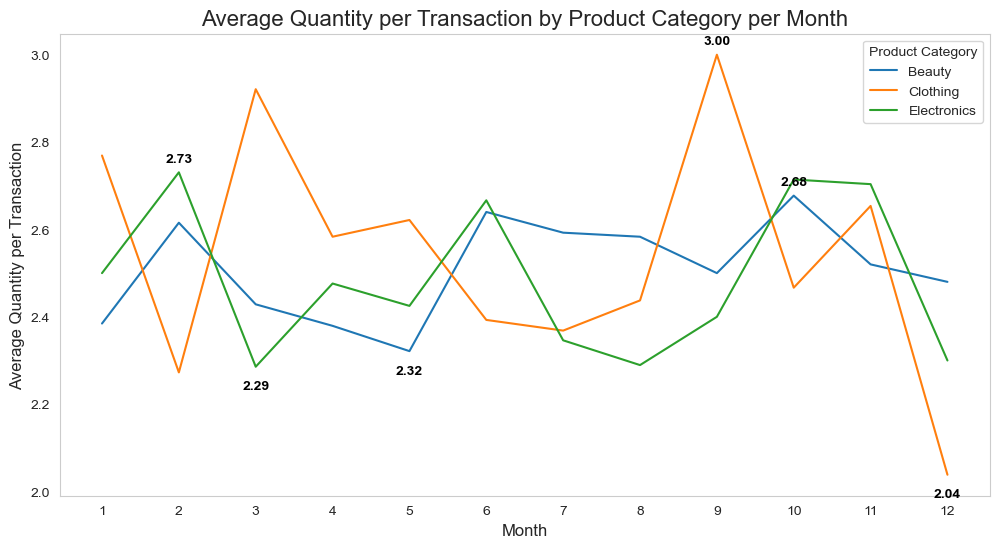

In [11]:
### Q5 What are the patterns in purchase quantity per transaction?
##  To find patterns 
#   Average Quantity per Transaction
avg_quantity = df['Quantity'].mean()
print(f"Average Quantity per Transaction: {avg_quantity:.2f}")

# Optional: average quantity by product category
avg_quantity_by_product = df.groupby('Product Category')['Quantity'].mean().reset_index()
print("\nTable 5A: Average Quantity per Transaction by Product Category:")
display(avg_quantity_by_product)


## Average Quantity per Transaction by Product and Month
# Group by Month & Product Category
avg_qty_month_product = df.groupby(['Month','Product Category']).agg(
    Avg_Quantity=('Quantity', 'mean')
).reset_index()

# Pivot table: Months as rows, Products as columns, values = Avg_Quantity
avg_qty_pivot = avg_qty_month_product.pivot(
    index='Month',
    columns='Product Category',
    values='Avg_Quantity'
)

# Fill missing values with 0 (if any) and round to 2 decimals
avg_qty_pivot = avg_qty_pivot.fillna(0).round(2)

print("Table 5B: Average Quantity per Transaction by Product and Month")
display(avg_qty_pivot)

# Multi-line chart 
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

for product in avg_qty_month_product['Product Category'].unique():
    product_data = avg_qty_month_product[avg_qty_month_product['Product Category'] == product]
    
    # Plot line without markers
    plt.plot(product_data['Month'], product_data['Avg_Quantity'], label=product)
    
    # Annotate highest point
    max_idx = product_data['Avg_Quantity'].idxmax()
    max_month = product_data.loc[max_idx, 'Month']
    max_val = product_data.loc[max_idx, 'Avg_Quantity']
    plt.annotate(f"{max_val:.2f}", 
                 xy=(max_month, max_val),
                 xytext=(0, 5), 
                 textcoords='offset points',
                 ha='center', va='bottom',
                 fontsize=10, color='black',
                 fontweight='bold')
    
    # Annotate lowest point
    min_idx = product_data['Avg_Quantity'].idxmin()
    min_month = product_data.loc[min_idx, 'Month']
    min_val = product_data.loc[min_idx, 'Avg_Quantity']
    plt.annotate(f"{min_val:.2f}", 
                 xy=(min_month, min_val),
                 xytext=(0, -10), 
                 textcoords='offset points',
                 ha='center', va='top',
                 fontsize=10, color='black',
                 fontweight='bold')

plt.title('Average Quantity per Transaction by Product Category per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Quantity per Transaction', fontsize=12)
plt.xticks(range(1,13))
plt.legend(title='Product Category')
plt.grid(False)
plt.show()

In [12]:
### Q6 How does pricing affect purchasing behavior?
##  To find relation between price and quantity 
#   Pricing Summary
price_summary = df.groupby('Price per Unit').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Quantity=('Quantity', 'mean')
).reset_index()

# Display table heading
print("Table 6A: Pricing Summary Table")
display(price_summary)

## Pivoted Pricing by Product
# Aggregate metrics by Price per Unit and Product Category
price_product_summary = df.groupby(['Price per Unit', 'Product Category']).agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Transactions=('Transaction ID', 'nunique'),
    Avg_Quantity=('Quantity', 'mean')
).reset_index()

# Pivot table for Total Revenue
revenue_pivot = price_product_summary.pivot(index='Price per Unit', columns='Product Category', values='Total_Revenue')
revenue_pivot = revenue_pivot.fillna(0)  # fill missing values
revenue_pivot = revenue_pivot.map(lambda x: f"${x:,.0f}")  # format as currency

print("\nTable 6B: Total Revenue per Product by Price")
display(revenue_pivot)

Table 6A: Pricing Summary Table


,Price per Unit,Total_Revenue,Total_Transactions,Avg_Quantity
0,25,13050,210,2.485714
1,30,13350,183,2.431694
2,50,26700,211,2.530806
3,300,155400,197,2.629442
4,500,247500,199,2.487437



Table 6B: Total Revenue per Product by Price


Product Category,Beauty,Clothing,Electronics
Price per Unit,,,
25,"$3,925","$4,600","$4,525"
30,"$3,990","$5,130","$4,230"
50,"$8,500","$9,450","$8,750"
300,"$42,600","$57,900","$54,900"
500,"$84,500","$78,500","$84,500"


Table 2: Top 20 Customers at Risk of Becoming Inactive


,Customer ID,Days_Since_Last_Purchase,Total_Transactions,Purchase_Frequency,Spending_Trend_Pct,Total_Spent,Churn_Risk_Score,Risk_Level
1,CUST303,365,1,0.0,0.0,90,85.0,High Risk
2,CUST421,365,1,0.0,0.0,1500,85.0,High Risk
3,CUST180,366,1,0.0,0.0,900,85.0,High Risk
4,CUST163,365,1,0.0,0.0,150,85.0,High Risk
5,CUST559,366,1,0.0,0.0,1200,85.0,High Risk
6,CUST979,365,1,0.0,0.0,25,85.0,High Risk
7,CUST522,366,1,0.0,0.0,1500,85.0,High Risk
8,CUST231,363,1,0.0,0.0,150,84.9,High Risk
9,CUST683,363,1,0.0,0.0,1000,84.9,High Risk
10,CUST610,364,1,0.0,0.0,600,84.9,High Risk


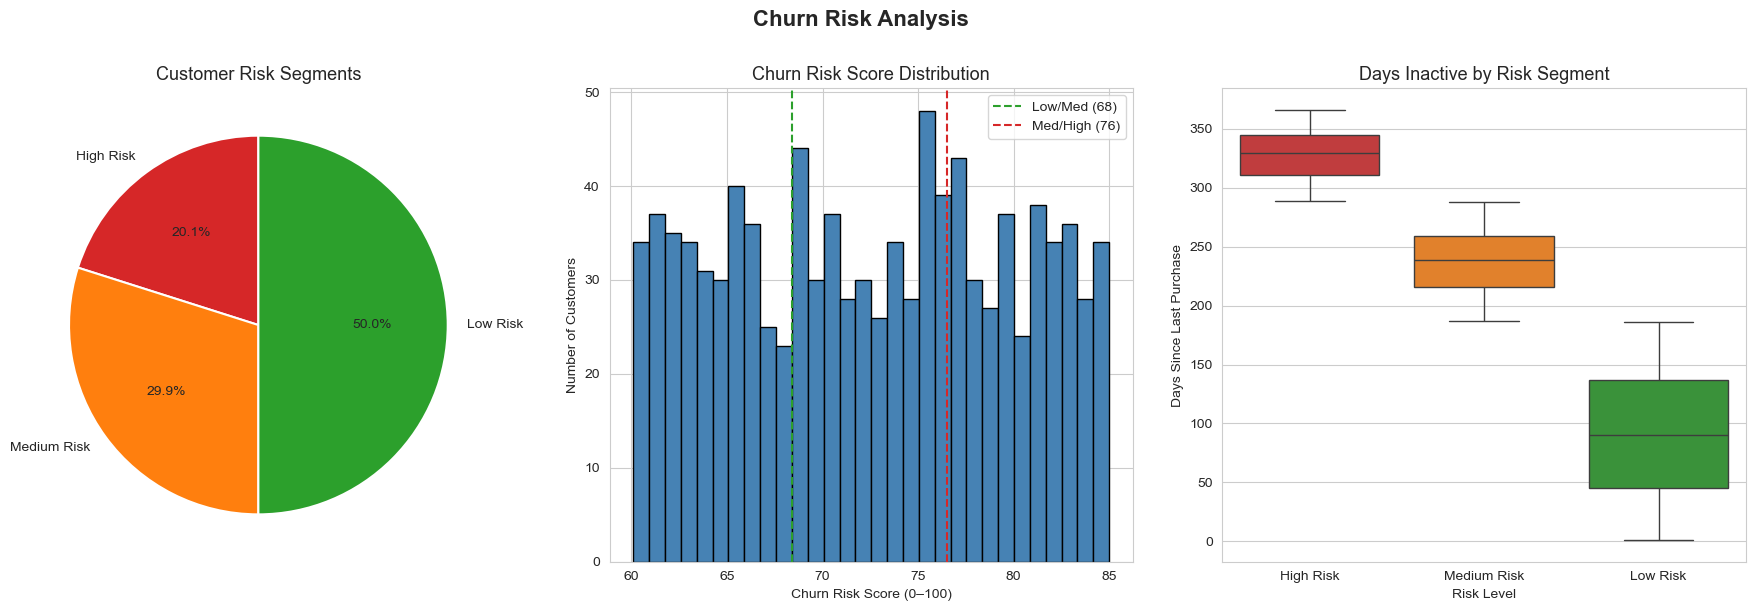

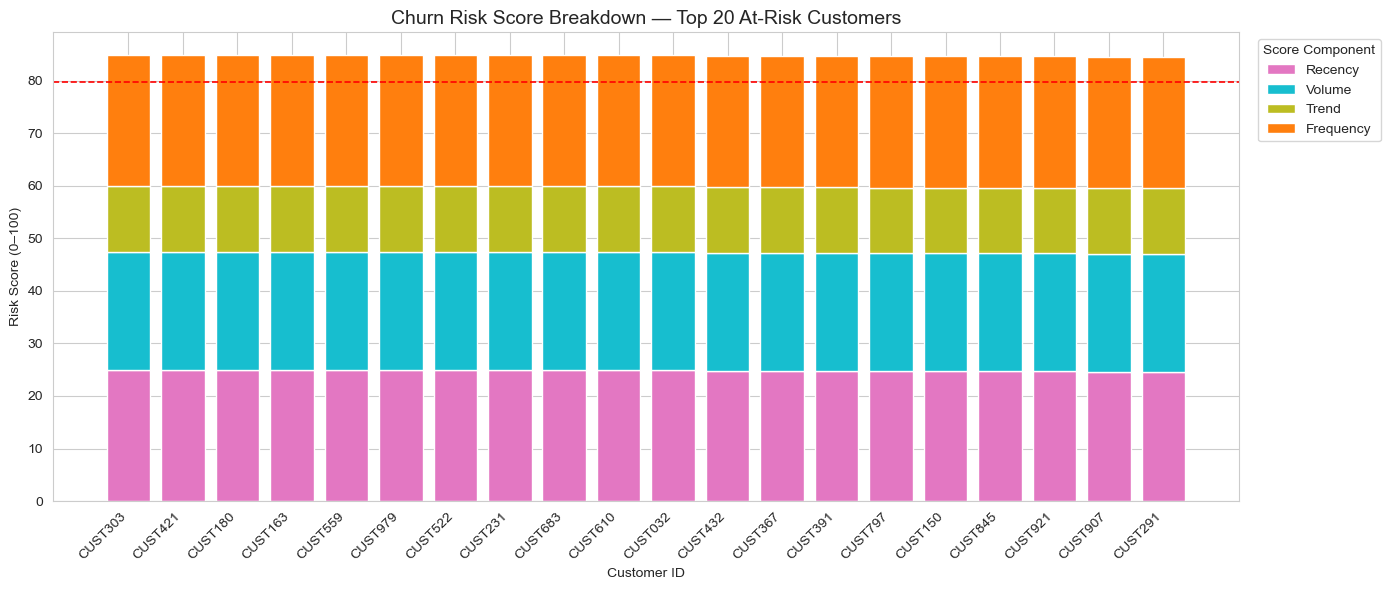

Table 3: Customer Churn Risk Segment Summary


,Risk Level,Customers,Average Risk Score,Average Days Inactive,Average Transactions,Average Spending Trend (%),Average Total Spent
0,High Risk,201,82.5,328.2,1.0,0.0,461.8
1,Medium Risk,299,76.3,238.4,1.0,0.0,462.8
2,Low Risk,500,66.3,91.5,1.0,0.0,449.6


Risk Thresholds → Low: < 72.8 | Medium: 72.8 – 79.8 | High: ≥ 79.8


In [13]:
### Q7 Customer Retention and Activity Analysis
##  Churn Risk Analysis — Recency, Frequency, Volume, Spending Trend 
#   Reference date & per-customer metrics
df['Date'] = pd.to_datetime(df['Date'])
reference_date = df['Date'].max() + pd.Timedelta(days=1)

churn_df = df.groupby('Customer ID').agg(
    Last_Purchase        = ('Date',          'max'),
    First_Purchase       = ('Date',          'min'),
    Total_Transactions   = ('Transaction ID','nunique'),
    Total_Spent          = ('Total Amount',   'sum'),
    Avg_Order_Value      = ('Total Amount',   'mean'),
    Age                  = ('Age',            'first'),
    Gender               = ('Gender',         'first'),
).reset_index()

# Days since last purchase (Recency)
churn_df['Days_Since_Last_Purchase'] = (reference_date - churn_df['Last_Purchase']).dt.days

# Purchase frequency (repeat purchases per month)
churn_df['Lifespan_Days'] = (churn_df['Last_Purchase'] - churn_df['First_Purchase']).dt.days.clip(lower=0)
churn_df['Purchase_Frequency'] = np.where(
    churn_df['Total_Transactions'] <= 1,
    0.0,
    ((churn_df['Total_Transactions'] - 1) / (churn_df['Lifespan_Days'] / 30)).round(3)
)

# Spending trend (% change: early-half vs late-half transactions)
def spending_trend(group):
    if len(group) < 2:
        return 0.0
    group = group.sort_values('Date')
    mid = len(group) // 2
    early_avg = group.iloc[:mid]['Total Amount'].mean()
    late_avg  = group.iloc[mid:]['Total Amount'].mean()
    return round((late_avg - early_avg) / early_avg * 100, 2) if early_avg != 0 else 0.0

trend = df.groupby('Customer ID').apply(spending_trend, include_groups=False)
trend.name = 'Spending_Trend_Pct'
churn_df = churn_df.merge(trend, on='Customer ID', how='left')

# Risk scoring (each component 0–25 pts, total 0–100)
MAX_INACTIVE_DAYS = 365
MAX_TRANSACTIONS  = 10
MAX_FREQ          = 2.0

churn_df['Score_Recency']   = ((churn_df['Days_Since_Last_Purchase'].clip(upper=MAX_INACTIVE_DAYS) / MAX_INACTIVE_DAYS) * 25).round(1)
churn_df['Score_Volume']    = ((1 - churn_df['Total_Transactions'].clip(upper=MAX_TRANSACTIONS) / MAX_TRANSACTIONS) * 25).round(1)
churn_df['Score_Trend']     = (((-churn_df['Spending_Trend_Pct'].clip(lower=-100, upper=100) + 100) / 200) * 25).round(1)
churn_df['Score_Frequency'] = ((1 - churn_df['Purchase_Frequency'].clip(upper=MAX_FREQ) / MAX_FREQ) * 25).round(1)

churn_df['Churn_Risk_Score'] = (
    churn_df['Score_Recency'] + churn_df['Score_Volume'] +
    churn_df['Score_Trend']   + churn_df['Score_Frequency']
).round(1)

# Data-driven thresholds
p33 = churn_df['Churn_Risk_Score'].quantile(0.33)  # ← ADDED: Low/Medium boundary
p50 = churn_df['Churn_Risk_Score'].quantile(0.50)
p66 = churn_df['Churn_Risk_Score'].quantile(0.66)  # ← ADDED: Medium/High boundary
p80 = churn_df['Churn_Risk_Score'].quantile(0.80)

def assign_risk(score):
    if score >= p80:
        return 'High Risk'
    elif score >= p50:
        return 'Medium Risk'
    return 'Low Risk'

churn_df['Risk_Level'] = churn_df['Churn_Risk_Score'].apply(assign_risk)

# Top 20 at-risk customers
top_at_risk = (
    churn_df.sort_values('Churn_Risk_Score', ascending=False)
    .head(20)
    [['Customer ID', 'Days_Since_Last_Purchase', 'Total_Transactions',
      'Purchase_Frequency', 'Spending_Trend_Pct', 'Total_Spent', 'Churn_Risk_Score', 'Risk_Level']]
    .reset_index(drop=True)
)
top_at_risk.index += 1

print("Table 2: Top 20 Customers at Risk of Becoming Inactive")
display(top_at_risk)

# ── Plot 1: Risk segment distribution (pie) ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Churn Risk Analysis', fontsize=16, fontweight='bold', y=1.01)

segment_counts = churn_df['Risk_Level'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
colors_risk = ['#d62728', '#ff7f0e', '#2ca02c']

axes[0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    colors=colors_risk,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Customer Risk Segments', fontsize=13)

# Plot 2: Churn risk score distribution (histogram)
axes[1].hist(churn_df['Churn_Risk_Score'], bins=30, color='steelblue', edgecolor='black')
axes[1].axvline(p33, color='#2ca02c', linestyle='--', linewidth=1.5, label=f'Low/Med ({p33:.0f})')
axes[1].axvline(p66, color='#d62728', linestyle='--', linewidth=1.5, label=f'Med/High ({p66:.0f})')
axes[1].set_title('Churn Risk Score Distribution', fontsize=13)
axes[1].set_xlabel('Churn Risk Score (0–100)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

# Plot 3: Days inactive by risk segment (boxplot)
risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
sns.boxplot(
    data=churn_df,
    x='Risk_Level',
    y='Days_Since_Last_Purchase',
    order=risk_order,
    hue='Risk_Level',
    palette={'High Risk': '#d62728', 'Medium Risk': '#ff7f0e', 'Low Risk': '#2ca02c'},
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Days Inactive by Risk Segment', fontsize=13)
axes[2].set_xlabel('Risk Level')
axes[2].set_ylabel('Days Since Last Purchase')

plt.tight_layout()
plt.show()

# Plot 4: Score component breakdown (stacked bar — top 20 at risk)
top20 = churn_df.sort_values('Churn_Risk_Score', ascending=False).head(20)
score_cols   = ['Score_Recency', 'Score_Volume', 'Score_Trend', 'Score_Frequency']
score_colors = ['#e377c2', '#17becf', '#bcbd22', '#ff7f0e']
score_labels = ['Recency', 'Volume', 'Trend', 'Frequency']

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(top20))
for col, color, label in zip(score_cols, score_colors, score_labels):
    ax.bar(top20['Customer ID'], top20[col], bottom=bottom, color=color, label=label, edgecolor='white')
    bottom += top20[col].values

ax.set_title('Churn Risk Score Breakdown — Top 20 At-Risk Customers', fontsize=14)
ax.set_xlabel('Customer ID')
ax.set_ylabel('Risk Score (0–100)')
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20['Customer ID'], rotation=45, ha='right')
ax.legend(title='Score Component', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(p80, color='red', linestyle='--', linewidth=1.2, label=f'High Risk threshold ({p80:.0f})')
plt.tight_layout()
plt.show()

# Segment summary KPIs
segment_summary = (
    churn_df.groupby('Risk_Level')
    .agg(
        Customers          = ('Customer ID','count'),
        Avg_Risk_Score     = ('Churn_Risk_Score','mean'),
        Avg_Days_Inactive  = ('Days_Since_Last_Purchase','mean'),
        Avg_Transactions   = ('Total_Transactions','mean'),
        Avg_Spend_Trend    = ('Spending_Trend_Pct','mean'),
        Avg_Total_Spent    = ('Total_Spent', 'mean'),
    )
    .round(1)
    .reindex(['High Risk', 'Medium Risk', 'Low Risk'])
)

segment_summary_display = segment_summary.reset_index()

print("Table 3: Customer Churn Risk Segment Summary")
segment_summary_display.columns = [
    'Risk Level',
    'Customers',
    'Average Risk Score',
    'Average Days Inactive',
    'Average Transactions',
    'Average Spending Trend (%)',
    'Average Total Spent'
]
display(segment_summary_display)

print(
    f"Risk Thresholds → "
    f"Low: < {p50:.1f} | "
    f"Medium: {p50:.1f} – {p80:.1f} | "
    f"High: ≥ {p80:.1f}"
)